## Step 1: Import Libraries and Load Data

First, we'll import the necessary libraries for data manipulation, modeling, and visualization. We will then load the `bank-additional-full.csv` dataset.

**Note on GPU Support (`cuml`):**
To run the model on a GPU, you need an NVIDIA GPU and the RAPIDS `cuml` library. Installation can be complex. If you don't have this setup, you can simply run the CPU part of this notebook (using `scikit-learn`), which is the standard approach.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Scikit-learn for CPU-based CART model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder



# Set plot style
plt.style.use('ggplot')

# Load the dataset
# The dataset uses semicolons as separators
df = pd.read_csv('/mnt/c/Users/sudee/Desktop/work/Enhancing-CART-with-a-K-Means-and-Random-Forest-Ensemble-for-Robust-Segmentation/bank+marketing/bank/bank-full.csv', sep=';')

print("Dataset loaded successfully!")
df.head()

RAPIDS cuML not found. GPU functionality will be disabled.
Dataset loaded successfully!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## Step 2: Data Cleaning and Preprocessing

Here, we'll prepare the data for modeling. This involves:
1.  **Dropping the 'duration' column**: As the data description file (`bank-additional-names.txt`) warns, this feature is not known before a call is made and highly affects the output, making it a data leak. For a realistic predictive model, it should be removed.
2.  **Encoding the Target Variable**: We will convert the target variable `y` from "yes"/"no" to 1/0.
3.  **Handling Categorical Features**: We'll use one-hot encoding to convert categorical columns into a numerical format that the model can understand. The description file notes that missing values are coded as "unknown", which we will treat as a distinct category.
4.  **Splitting the Data**: We will split the data into training and testing sets.

In [3]:
print("Starting data cleaning and preprocessing...")

# Drop the 'duration' column as recommended for a realistic model
df_cleaned = df.drop('duration', axis=1)
print("Dropped 'duration' column.")

# Convert target variable 'y' to binary (0 for 'no', 1 for 'yes')
df_cleaned['y'] = df_cleaned['y'].map({'no': 0, 'yes': 1})

# Separate features (X) and target (y)
X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

# One-hot encode all categorical features
# This will automatically handle columns with text data
X_encoded = pd.get_dummies(X, drop_first=True)
print("Categorical features have been one-hot encoded.")
print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after encoding: {X_encoded.shape[1]}")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData has been split into training and testing sets.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Starting data cleaning and preprocessing...
Dropped 'duration' column.
Categorical features have been one-hot encoded.
Original number of features: 15
Number of features after encoding: 41

Data has been split into training and testing sets.
Training set shape: (36168, 41)
Testing set shape: (9043, 41)


## Step 3: Build and Train the CART Model (CPU Approach)

We will now build and train our Classification and Regression Tree (CART) model using `scikit-learn`. CART models are trained in a single pass and do not use epochs. Instead of a progress bar for epochs, we will time the training process and then evaluate its performance by looking at key metrics.

We'll look at:
- **Accuracy**: The overall percentage of correct predictions.
- **Classification Report**: Provides precision, recall, and F1-score for each class.
- **Confusion Matrix**: Shows the number of true positives, true negatives, false positives, and false negatives.

--- Training CART Model on CPU ---
Training the model...
Model training complete.

--- CPU Model Evaluation ---
Accuracy: 0.7959

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.83      0.88      7985
         Yes       0.30      0.56      0.39      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.69      0.63      9043
weighted avg       0.86      0.80      0.82      9043

Confusion Matrix:


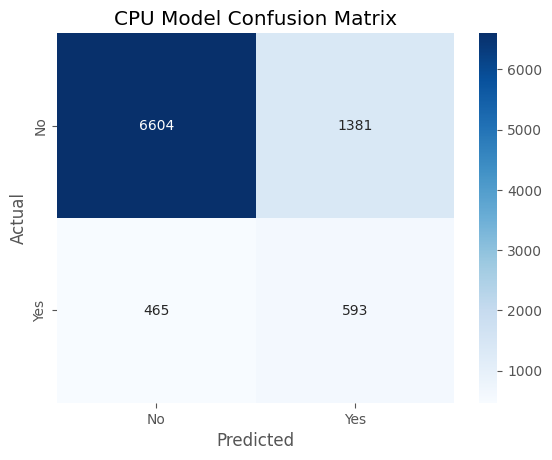

In [ ]:
# --- Training CART Model on CPU ---
print("--- Training CART Model on CPU ---")

# Initialize the Decision Tree Classifier (CART)
cart_cpu = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

# Train the model
print("Training the model...")
cart_cpu.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_cpu = cart_cpu.predict(X_test)

# --- Evaluate the Model ---
print("\n--- CPU Model Evaluation ---")

# Calculate accuracy
accuracy_cpu = accuracy_score(y_test, y_pred_cpu)
print(f"Accuracy: {accuracy_cpu:.4f}")

# Display the classification report for detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cpu, target_names=['No', 'Yes']))

# Display the confusion matrix
print("Confusion Matrix:")
cm_cpu = confusion_matrix(y_test, y_pred_cpu)
sns.heatmap(cm_cpu, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CPU Model Confusion Matrix')
plt.show()  

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Define the parameter grid for the CART model (no n_estimators)
cart_param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# 2. Initialize and run the Grid Search for the Decision Tree
cart_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=cart_param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1
)

print("Starting Grid Search for the CART model...")
cart_grid_search.fit(X_train, y_train)

# 3. Print the best parameters found for the CART model
print(f"\nBest parameters for CART model: {cart_grid_search.best_params_}")

Starting Grid Search for the CART model...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters for CART model: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}


Training the final, optimized CART model...
Training complete.

--- Final Optimized CART Model Evaluation ---
              precision    recall  f1-score   support

          No       0.94      0.85      0.89      7985
         Yes       0.34      0.57      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.71      0.66      9043
weighted avg       0.87      0.82      0.84      9043


Confusion Matrix:


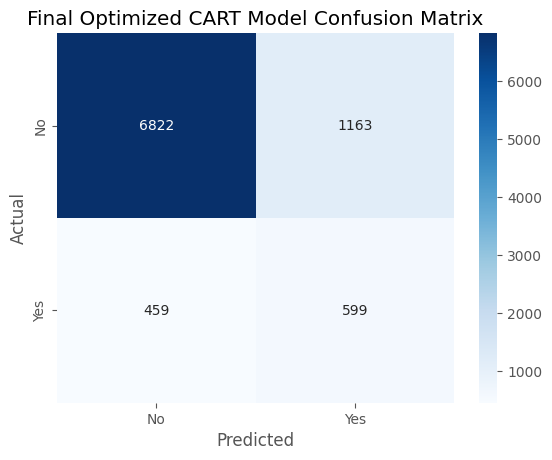

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the final CART model with the BEST parameters found
final_cart_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # Keep this for the imbalanced data
)

# Train the final model on the full training dataset
print("Training the final, optimized CART model...")
final_cart_model.fit(X_train, y_train)
print("Training complete.")

# Evaluate the final model on the test set
y_pred_final = final_cart_model.predict(X_test)

print("\n--- Final Optimized CART Model Evaluation ---")
print(classification_report(y_test, y_pred_final, target_names=['No', 'Yes']))


# --- ADDED: Display the confusion matrix ---
print("\nConfusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Optimized CART Model Confusion Matrix')
plt.show()